In [1]:
# Load Imports

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import AllChem

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [5]:
import json

with open("data/drug_master.json", "r") as f:
    drug_master = json.load(f)

In [6]:
type(drug_master)

dict

In [7]:
if isinstance(drug_master, dict):
    print(drug_master.keys())
else:
    print("Number of entries:", len(drug_master))
    print(drug_master[0])

dict_keys(['be-2254', 'tasimelteon', 'esaxerenone', 'ixazomib-citrate', 'alendronate', 'dazmegrel', 'nobiletin', 'azd7986', 'bebt-908', 'nitromide', 'saroglitazar', 'l-368899', 'betamethasone-valerate', '2-methylimidazole', 'pnu-282987', 'kx2-391', 'asivatrep', 'diclofenac', 'emeramide', 'hemado', 'proadifen', 'simvastatin', 'gabexate', 'cis-aconitic-acid', 'thioperamide', 'methicillin', 'capadenoson', 'fluvoxamine', 'cp-316819', 'bay-11-7085', 'capsazepine', 'montelukast', 'cgp-52411', 'sym-2206', 'pac-1', 'tenofovir-disoproxil', 'relebactam', 'cerulenin', 'gr-135531', 'pipotiazine-palmitate', 'erlotinib', 'farnesyl-thiosalicylic-acid-amide', 'losmapimod', 'ru-42173', '(r)-baclofen', 'raloxifene', 'butaprost', 'aee788', 'thiamet-g', 'mek1-2-inhibitor', 'abamectin', 'gsk356278', 'salinomycin', 'riodoxol', 'umeclidinium', 'a922500', 'dextran', 'pf-4191834', 'ursodeoxycholyltaurine', 'ethynodiol-diacetate', 'oxyclozanide', 'terreic-acid-(-)', 'cb-5083', 'pindolol-(-)', 'ambrisentan', 'se

In [8]:
first_drug_name = next(iter(drug_master))

print("First drug name:", first_drug_name)
print(drug_master[first_drug_name])

First drug name: be-2254
{'name': 'be-2254', 'pubchem_cid': '86308637', 'inchi_key': 'PZZOEXPDTYIBPI-MRXNPFEDSA-N', 'smiles': 'Oc1ccc(CCNC[C@H]2CCc3ccccc3C2=O)cc1 |r|', 'broad_id': 'BRD-A24429032-003-03-2', 'moa': 'adrenergic receptor antagonist', 'target': 'ADRA1A', 'clinical_phase': 'Phase 2', 'disease_area': '', 'indication': '', 'fda_approved': False}


In [9]:
records = []

for drug_name, info in drug_master.items():
    records.append({
        "drug_name": drug_name,
        "pubchem_cid": info.get("pubchem_cid"),
        "smiles": info.get("smiles"),
        "moa": info.get("moa"),
        "target": info.get("target"),
        "fda_approved": info.get("fda_approved")
    })

df = pd.DataFrame(records)

print(df.shape)
df.head()

(6801, 6)


,drug_name,pubchem_cid,smiles,moa,target,fda_approved
0,be-2254,86308637,Oc1ccc(CCNC[C@H]2CCc3ccccc3C2=O)cc1 |r|,adrenergic receptor antagonist,ADRA1A,False
1,tasimelteon,10220503,CCC(=O)NC[C@@H]1C[C@H]1c1cccc2OCCc12,melatonin receptor agonist,MTNR1A|MTNR1B,True
2,esaxerenone,25052023,Cc1c(cn(CCO)c1-c1ccccc1C(F)(F)F)C(=O)Nc1ccc(cc...,mineralocorticoid receptor antagonist,,False
3,ixazomib-citrate,69040311,CC(C)C[C@H](NC(=O)CNC(=O)c1cc(Cl)ccc1Cl)B1OC(=...,proteasome inhibitor,,True
4,alendronate,44400013,NCCCC(O)(P(O)(O)=O)P(O)(O)=O,bone resorption inhibitor,ATP6V1A|FDPS|PTPN4|PTPRE|PTPRS,True


In [10]:
print("Missing SMILES:", df["smiles"].isna().sum())
print("Total compounds:", len(df))

Missing SMILES: 0
Total compounds: 6801


In [11]:
df["mol"] = df["smiles"].apply(Chem.MolFromSmiles)

print("Invalid RDKit molecules:", df["mol"].isna().sum())

Invalid RDKit molecules: 22


In [12]:
df = df[df["mol"].notna()].copy()

print("Remaining valid compounds:", len(df))

Remaining valid compounds: 6779


In [13]:
from rdkit import DataStructs
from rdkit.Chem import rdFingerprintGenerator

morgan_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)

def mol_to_morgan_array(mol, n_bits=2048):
    fp = morgan_generator.GetFingerprint(mol)

    arr = np.zeros((n_bits,), dtype=np.float32)
    DataStructs.ConvertToNumpyArray(fp, arr)

    return arr

In [14]:
X = np.vstack(
    df["mol"].apply(mol_to_morgan_array).values
)

print("Morgan fingerprint matrix shape:", X.shape)
print("Unique values:", np.unique(X))
print("Average active bits per compound:", X.sum(axis=1).mean())

Morgan fingerprint matrix shape: (6779, 2048)
Unique values: [0. 1.]
Average active bits per compound: 44.54241


In [15]:
X_train, X_temp = train_test_split(
    X,
    test_size=0.30,
    random_state=42
)

X_val, X_test = train_test_split(
    X_temp,
    test_size=0.50,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (4745, 2048)
Validation: (1017, 2048)
Test: (1017, 2048)


In [22]:
train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32)
)

val_dataset = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32)
)

test_dataset = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [21]:
class MorganAutoencoder(nn.Module):
    def __init__(self, input_dim=2048, latent_dim=15):
        super().__init__()

        # Compress 2048 Morgan bits down to 15 learned numbers
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),

            nn.Linear(512, 128),
            nn.ReLU(),

            nn.Linear(128, latent_dim)
        )

        # Expand those 15 numbers back into 2048 Morgan-bit probabilities
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 512),
            nn.ReLU(),

            nn.Linear(512, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        latent_vector = self.encoder(x)
        reconstruction = self.decoder(latent_vector)

        return reconstruction, latent_vector

In [23]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = MorganAutoencoder(
    input_dim=X.shape[1],
    latent_dim=15
).to(device)

criterion = nn.BCELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Using device:", device)
print(model)

Using device: cpu
MorganAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=2048, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=15, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=15, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=2048, bias=True)
    (5): Sigmoid()
  )
)


In [24]:
num_epochs = 50

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training phase
    model.train()
    total_train_loss = 0

    for (batch,) in train_loader:
        batch = batch.to(device)

        reconstruction, _ = model(batch)
        loss = criterion(reconstruction, batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * batch.size(0)

    avg_train_loss = total_train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    # Validation phase
    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for (batch,) in val_loader:
            batch = batch.to(device)

            reconstruction, _ = model(batch)
            loss = criterion(reconstruction, batch)

            total_val_loss += loss.item() * batch.size(0)

    avg_val_loss = total_val_loss / len(val_loader.dataset)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"Train: {avg_train_loss:.4f} | "
        f"Val: {avg_val_loss:.4f}"
    )

Epoch 01/50 | Train: 0.1808 | Val: 0.0841
Epoch 02/50 | Train: 0.0819 | Val: 0.0801
Epoch 03/50 | Train: 0.0799 | Val: 0.0780
Epoch 04/50 | Train: 0.0779 | Val: 0.0764
Epoch 05/50 | Train: 0.0754 | Val: 0.0739
Epoch 06/50 | Train: 0.0733 | Val: 0.0725
Epoch 07/50 | Train: 0.0714 | Val: 0.0708
Epoch 08/50 | Train: 0.0691 | Val: 0.0689
Epoch 09/50 | Train: 0.0667 | Val: 0.0676
Epoch 10/50 | Train: 0.0649 | Val: 0.0667
Epoch 11/50 | Train: 0.0632 | Val: 0.0661
Epoch 12/50 | Train: 0.0616 | Val: 0.0652
Epoch 13/50 | Train: 0.0601 | Val: 0.0647
Epoch 14/50 | Train: 0.0584 | Val: 0.0639
Epoch 15/50 | Train: 0.0568 | Val: 0.0631
Epoch 16/50 | Train: 0.0551 | Val: 0.0631
Epoch 17/50 | Train: 0.0536 | Val: 0.0622
Epoch 18/50 | Train: 0.0519 | Val: 0.0619
Epoch 19/50 | Train: 0.0503 | Val: 0.0617
Epoch 20/50 | Train: 0.0488 | Val: 0.0618
Epoch 21/50 | Train: 0.0474 | Val: 0.0622
Epoch 22/50 | Train: 0.0460 | Val: 0.0623
Epoch 23/50 | Train: 0.0446 | Val: 0.0627
Epoch 24/50 | Train: 0.0432 | Val:

In [28]:
import os
os.makedirs("models", exist_ok=True)

In [29]:
# Reinitialize a fresh model before retraining
model = MorganAutoencoder(
    input_dim=X.shape[1],
    latent_dim=15
).to(device)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 100
patience = 5

best_val_loss = float("inf")
epochs_without_improvement = 0

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0

    for (batch,) in train_loader:
        batch = batch.to(device)

        reconstruction, _ = model(batch)
        loss = criterion(reconstruction, batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * batch.size(0)

    avg_train_loss = total_train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for (batch,) in val_loader:
            batch = batch.to(device)

            reconstruction, _ = model(batch)
            loss = criterion(reconstruction, batch)

            total_val_loss += loss.item() * batch.size(0)

    avg_val_loss = total_val_loss / len(val_loader.dataset)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch {epoch + 1:02d} | "
        f"Train: {avg_train_loss:.4f} | "
        f"Val: {avg_val_loss:.4f}"
    )

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_without_improvement = 0

        torch.save(
            model.state_dict(),
            "models/morgan_autoencoder_best.pt"
        )
    else:
        epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break

Epoch 01 | Train: 0.1766 | Val: 0.0834
Epoch 02 | Train: 0.0817 | Val: 0.0799
Epoch 03 | Train: 0.0800 | Val: 0.0784
Epoch 04 | Train: 0.0779 | Val: 0.0765
Epoch 05 | Train: 0.0762 | Val: 0.0747
Epoch 06 | Train: 0.0740 | Val: 0.0729
Epoch 07 | Train: 0.0720 | Val: 0.0716
Epoch 08 | Train: 0.0702 | Val: 0.0700
Epoch 09 | Train: 0.0679 | Val: 0.0684
Epoch 10 | Train: 0.0656 | Val: 0.0669
Epoch 11 | Train: 0.0635 | Val: 0.0663
Epoch 12 | Train: 0.0617 | Val: 0.0648
Epoch 13 | Train: 0.0599 | Val: 0.0642
Epoch 14 | Train: 0.0582 | Val: 0.0635
Epoch 15 | Train: 0.0566 | Val: 0.0632
Epoch 16 | Train: 0.0550 | Val: 0.0624
Epoch 17 | Train: 0.0534 | Val: 0.0620
Epoch 18 | Train: 0.0518 | Val: 0.0620
Epoch 19 | Train: 0.0504 | Val: 0.0618
Epoch 20 | Train: 0.0489 | Val: 0.0618
Epoch 21 | Train: 0.0475 | Val: 0.0620
Epoch 22 | Train: 0.0461 | Val: 0.0621
Epoch 23 | Train: 0.0448 | Val: 0.0625
Epoch 24 | Train: 0.0434 | Val: 0.0633
Early stopping at epoch 24


In [30]:
model.load_state_dict(
    torch.load("models/morgan_autoencoder_best.pt", map_location=device)
)

model.eval()

print("Best model loaded.")

Best model loaded.


In [31]:
X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
).to(device)

with torch.no_grad():
    X_test_reconstructed, Z_test = model(X_test_tensor)

X_test_reconstructed = X_test_reconstructed.cpu().numpy()
Z_test = Z_test.cpu().numpy()

print("Reconstructed test matrix:", X_test_reconstructed.shape)
print("Test latent matrix:", Z_test.shape)

Reconstructed test matrix: (1017, 2048)
Test latent matrix: (1017, 15)


In [32]:
X_test_predicted_bits = (X_test_reconstructed >= 0.5).astype(int)

In [33]:
from sklearn.metrics import f1_score, roc_auc_score

# Raw bitwise accuracy
bitwise_accuracy = (X_test_predicted_bits == X_test).mean()

# Per-compound F1 score
f1_scores = [
    f1_score(true_bits, pred_bits, zero_division=0)
    for true_bits, pred_bits in zip(X_test, X_test_predicted_bits)
]

# Per-compound ROC-AUC using the model's probabilities
auc_scores = [
    roc_auc_score(true_bits, predicted_probs)
    for true_bits, predicted_probs in zip(X_test, X_test_reconstructed)
    if len(np.unique(true_bits)) > 1
]

print("Bitwise accuracy:", round(bitwise_accuracy, 4))
print("Mean F1:", round(np.mean(f1_scores), 4))
print("Median F1:", round(np.median(f1_scores), 4))
print("Mean ROC-AUC:", round(np.mean(auc_scores), 4))
print("Median ROC-AUC:", round(np.median(auc_scores), 4))

Bitwise accuracy: 0.9847
Mean F1: 0.4996
Median F1: 0.4828
Mean ROC-AUC: 0.8945
Median ROC-AUC: 0.8964


In [34]:
# Run every valid compound through the trained encoder
X_tensor = torch.tensor(X, dtype=torch.float32).to(device)

model.eval()

with torch.no_grad():
    _, Z_all = model(X_tensor)

Z_all = Z_all.cpu().numpy()

print("Latent matrix shape:", Z_all.shape)

Latent matrix shape: (6779, 15)


In [35]:
latent_df = pd.DataFrame(
    Z_all,
    columns=[f"latent_{i+1}" for i in range(Z_all.shape[1])]
)

latent_output = pd.concat(
    [
        df.drop(columns=["mol"]).reset_index(drop=True),
        latent_df
    ],
    axis=1
)

latent_output.to_csv(
    "data/morgan_autoencoder_latent15.csv",
    index=False
)

latent_output.head()

,drug_name,pubchem_cid,smiles,moa,target,fda_approved,latent_1,latent_2,latent_3,latent_4,...,latent_6,latent_7,latent_8,latent_9,latent_10,latent_11,latent_12,latent_13,latent_14,latent_15
0,be-2254,86308637,Oc1ccc(CCNC[C@H]2CCc3ccccc3C2=O)cc1 |r|,adrenergic receptor antagonist,ADRA1A,False,-4.386113,4.102465,6.216204,-0.258673,...,4.865364,-0.097368,-2.821692,-0.424079,-0.610536,4.111461,-9.053070,3.182982,-7.019077,-2.648253
1,tasimelteon,10220503,CCC(=O)NC[C@@H]1C[C@H]1c1cccc2OCCc12,melatonin receptor agonist,MTNR1A|MTNR1B,True,-2.475837,5.107546,6.719912,1.081687,...,6.534824,0.361871,-2.504375,2.133189,0.012762,4.975464,-9.534292,5.091775,-2.380114,-0.712489
2,esaxerenone,25052023,Cc1c(cn(CCO)c1-c1ccccc1C(F)(F)F)C(=O)Nc1ccc(cc...,mineralocorticoid receptor antagonist,,False,-3.726033,-2.690629,4.366008,0.168400,...,6.027006,-2.272223,-4.440301,2.112492,0.621456,6.248229,-6.874542,-1.792286,-8.058927,3.917159
3,ixazomib-citrate,69040311,CC(C)C[C@H](NC(=O)CNC(=O)c1cc(Cl)ccc1Cl)B1OC(=...,proteasome inhibitor,,True,-1.931871,0.218309,3.973288,1.429336,...,3.248253,0.714166,-2.344715,1.542596,-1.520865,5.442096,-2.458892,1.029629,-5.838616,1.686733
4,alendronate,44400013,NCCCC(O)(P(O)(O)=O)P(O)(O)=O,bone resorption inhibitor,ATP6V1A|FDPS|PTPN4|PTPRE|PTPRS,True,-3.904385,4.114501,7.306038,2.166590,...,0.395244,-6.051449,-2.342308,3.699525,-2.897161,8.015383,-3.243589,1.271625,-4.694563,0.326533


In [1]:
import umap.umap_ as umap

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [36]:
%pip install umap-learn

Note: you may need to restart the kernel to use updated packages.


In [37]:
# Recreate the model object
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MorganAutoencoder(
    input_dim=X.shape[1],
    latent_dim=15
).to(device)

model.load_state_dict(
    torch.load("models/morgan_autoencoder_best.pt", map_location=device)
)

model.eval()

MorganAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=2048, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=15, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=15, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=2048, bias=True)
    (5): Sigmoid()
  )
)

In [38]:
X_tensor = torch.tensor(X, dtype=torch.float32).to(device)

with torch.no_grad():
    _, Z_all = model(X_tensor)

Z_all = Z_all.cpu().numpy()

print("Latent matrix shape:", Z_all.shape)

Latent matrix shape: (6779, 15)


In [39]:
latent_umap = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

Z_umap = latent_umap.fit_transform(Z_all)

print(Z_umap.shape)

/opt/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(6779, 2)


In [40]:
latent_output["umap_1"] = Z_umap[:, 0]
latent_output["umap_2"] = Z_umap[:, 1]

latent_output.to_csv(
    "data/morgan_autoencoder_latent15_umap.csv",
    index=False
)

latent_output[["drug_name", "moa", "umap_1", "umap_2"]].head()

,drug_name,moa,umap_1,umap_2
0,be-2254,adrenergic receptor antagonist,1.632791,2.472047
1,tasimelteon,melatonin receptor agonist,1.900512,0.829345
2,esaxerenone,mineralocorticoid receptor antagonist,-0.131476,0.591217
3,ixazomib-citrate,proteasome inhibitor,0.510729,-2.350053
4,alendronate,bone resorption inhibitor,-0.893034,-5.001771


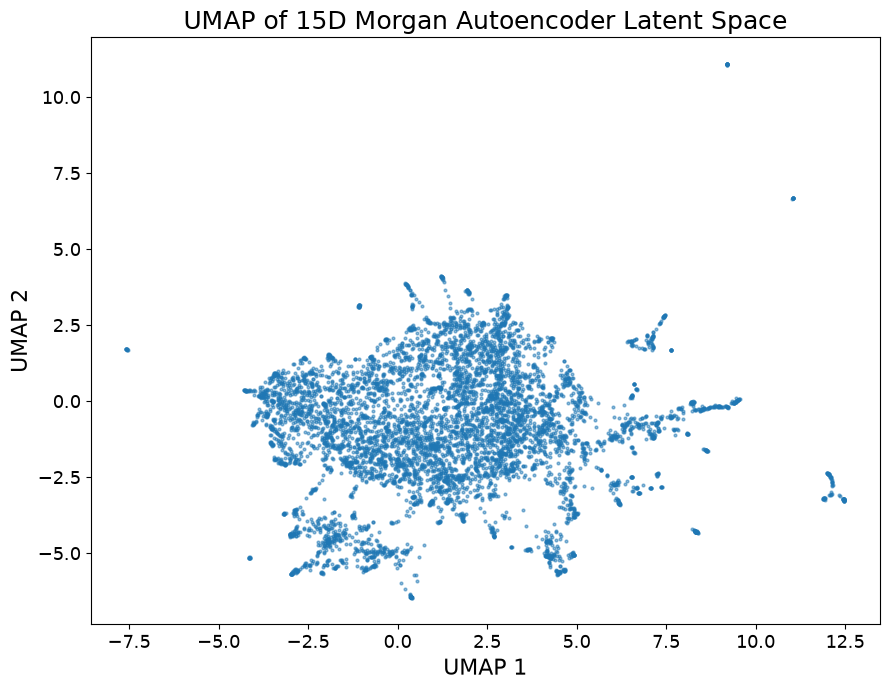

In [44]:
plt.figure(figsize=(9, 7))

plt.scatter(
    latent_output["umap_1"],
    latent_output["umap_2"],
    s=4,
    alpha=0.5
)

plt.xlabel("UMAP 1", fontsize=16)
plt.ylabel("UMAP 2", fontsize=16)
plt.title("UMAP of 15D Morgan Autoencoder Latent Space", fontsize=18)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.tight_layout()
plt.show()